In [1]:
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 16.2 MB/s eta 0:00:00


In [2]:
# Standard imports
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import rasterio
from rasterio.windows import Window
import xml.etree.ElementTree as ET

In [3]:
# # Go to your working directory (usually /content in Colab)
# !cd /content

# # Remove the old clone
# !rm -rf SAR4CET

In [4]:
# Clone the SAR4CET repository
import os
import subprocess
import sys
if not os.path.exists('SAR4CET'):
    print('Cloning SAR4CET repository...')
    result = subprocess.run(['git', 'clone', 'https://github.com/naikp13/SAR4CET.git'],
                           capture_output=True, text=True)
    if result.returncode == 0:
        print('Repository cloned successfully!')
    else:
        print(f'Error cloning repository: {result.stderr}')
else:
    print('SAR4CET directory already exists.')

# Install requirements
print('Installing SAR4CET requirements...')
if os.path.exists('SAR4CET/requirements.txt'):
    result = subprocess.run([sys.executable, '-m', 'pip', 'install', '-r', 'SAR4CET/requirements.txt'],
                           capture_output=True, text=True)
    if result.returncode == 0:
        print('Requirements installed successfully!')
    else:
        print(f'Error installing requirements: {result.stderr}')
        key_packages = ['openeo>=0.22.0', 'xarray>=0.19.0', 'numpy>=1.20.0',
                        'matplotlib>=3.4.0', 'rasterio>=1.2.0']
        for package in key_packages:
            subprocess.run([sys.executable, '-m', 'pip', 'install', package])
else:
    print('requirements.txt not found, installing key packages...')
    key_packages = ['openeo>=0.22.0', 'xarray>=0.19.0', 'numpy>=1.20.0',
                    'matplotlib>=3.4.0', 'rasterio>=1.2.0']
    for package in key_packages:
        subprocess.run([sys.executable, '-m', 'pip', 'install', package])

# Add SAR4CET to Python path
sar4cet_path = os.path.abspath('SAR4CET')
if sar4cet_path not in sys.path:
    sys.path.insert(0, sar4cet_path)
    print(f'Added {sar4cet_path} to Python path')

# Verify imports
try:
    import openeo
    import xarray as xr
    import matplotlib.pyplot as plt
    import numpy as np
    print('All required packages imported successfully!')
    print(f'openEO version: {openeo.__version__}')
    print(f'xarray version: {xr.__version__}')
except ImportError as e:
    print(f'Import error: {e}')
    print('Please install missing packages manually.')

Cloning SAR4CET repository...
Repository cloned successfully!
Installing SAR4CET requirements...
Requirements installed successfully!
Added /content/SAR4CET to Python path
All required packages imported successfully!
openEO version: 0.43.0
xarray version: 2025.1.1


In [5]:
# Add SAR4CET to path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# SAR4CET imports
from sar4cet.building_height import height_estimation
from sar4cet.visualization import plotting
from sar4cet.utils import io, conversions

# Configure matplotlib
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print('ICEYE Building Height Estimation')
print('-' * 60)

ICEYE Building Height Estimation
------------------------------------------------------------


In [6]:
"""## 2. ICEYE Data Loading Functions"""

def load_iceye_metadata(xml_path):
    """Load metadata from ICEYE XML file."""
    metadata = {}
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
        start_time = root.find('.//acquisition_start_utc')
        if start_time is not None:
            metadata['acquisition_date'] = start_time.text
        inc_center = root.find('.//incidence_center')
        if inc_center is not None:
            metadata['incidence_angle'] = float(inc_center.text)
        coord_center = root.find('.//coord_center')
        if coord_center is not None:
            try:
                coords = coord_center.text.split()
                if len(coords) >= 4:
                    metadata['center_lat'] = float(coords[2])
                    metadata['center_lon'] = float(coords[3])
                else:
                    print(f'Warning: Invalid coord_center format: {coord_center.text}')
            except (ValueError, IndexError) as e:
                print(f'Warning: Could not parse coord_center: {e}')
        az_spacing = root.find('.//azimuth_ground_spacing')
        if az_spacing is not None:
            metadata['row_spacing'] = float(az_spacing.text)
        slant_spacing = root.find('.//slant_range_spacing')
        if slant_spacing is not None and 'incidence_angle' in metadata:
            metadata['col_spacing'] = float(slant_spacing.text) / np.sin(np.radians(metadata['incidence_angle']))
        satellite_name = root.find('.//satellite_name')
        if satellite_name is not None:
            metadata['sensor'] = satellite_name.text
        else:
            metadata['sensor'] = 'ICEYE'
        mode = root.find('.//acquisition_mode')
        if mode is not None:
            metadata['mode'] = mode.text
        pol = root.find('.//polarization')
        if pol is not None:
            metadata['polarization'] = pol.text
        width = root.find('.//number_of_samples')
        height = root.find('.//number_of_lines')
        if width is not None and height is not None:
            metadata['cols'] = int(width.text)
            metadata['rows'] = int(height.text)
    except Exception as e:
        print(f'Warning: Could not parse metadata: {e}')
    return metadata

def load_iceye_preview(data_dir, tif_filename, max_pixels=1000):
    """Load a low-resolution preview of the ICEYE SAR image."""
    tif_path = os.path.join(data_dir, tif_filename)
    if not os.path.exists(tif_path):
        raise FileNotFoundError(f'TIFF file not found: {tif_path}')
    try:
        with rasterio.open(tif_path) as src:
            full_width = src.width
            full_height = src.height
            scale_factor = min(max_pixels / max(full_width, full_height), 1.0)
            out_width = int(full_width * scale_factor)
            out_height = int(full_height * scale_factor)
            preview = src.read(1, out_shape=(out_height, out_width), resampling=rasterio.enums.Resampling.bilinear).astype(np.float32)
            preview_db = 20 * np.log10(np.maximum(preview, 1e-10))
        return preview_db, full_width, full_height, scale_factor
    except Exception as e:
        raise RuntimeError(f'Error loading preview: {e}')

def load_iceye_data_subset(data_dir, tif_filename, row_off=0, col_off=0, subset_size=1000):
    """Load a subset of the ICEYE SAR image and metadata."""
    xml_files = [f for f in os.listdir(data_dir) if f.endswith('.xml')]
    if not xml_files:
        raise FileNotFoundError('No XML metadata file found in ICEYE folder')
    xml_path = os.path.join(data_dir, xml_files[0])
    metadata = load_iceye_metadata(xml_path)
    tif_path = os.path.join(data_dir, tif_filename)
    if not os.path.exists(tif_path):
        raise FileNotFoundError(f'TIFF file not found: {tif_path}')
    try:
        with rasterio.open(tif_path) as src:
            full_width = src.width
            full_height = src.height
            subset_width = min(subset_size, full_width - col_off)
            subset_height = min(subset_size, full_height - row_off)
            if subset_width <= 0 or subset_height <= 0:
                raise ValueError(f'Invalid subset dimensions: width={subset_width}, height={subset_height}')
            window = Window(col_off, row_off, subset_width, subset_height)
            sar_image = src.read(1, window=window).astype(np.float32)
            metadata['transform'] = src.window_transform(window)
            metadata['crs'] = src.crs
            metadata['bounds'] = src.window_bounds(window)
            metadata['rows'] = subset_height
            metadata['cols'] = subset_width
    except Exception as e:
        raise RuntimeError(f'Error loading TIFF subset: {e}')
    sar_image_db = 20 * np.log10(np.maximum(sar_image, 1e-10))
    metadata['data_type'] = 'ICEYE GRD'
    metadata['processing_level'] = 'L1'
    metadata['pixel_spacing_range'] = metadata.get('col_spacing', 1.0)
    metadata['pixel_spacing_azimuth'] = metadata.get('row_spacing', 1.0)
    return sar_image_db, metadata

In [7]:
from google.colab import drive
drive.mount("/content/drive/")

path = '/content/drive/MyDrive'

Mounted at /content/drive/


Loading ICEYE preview...


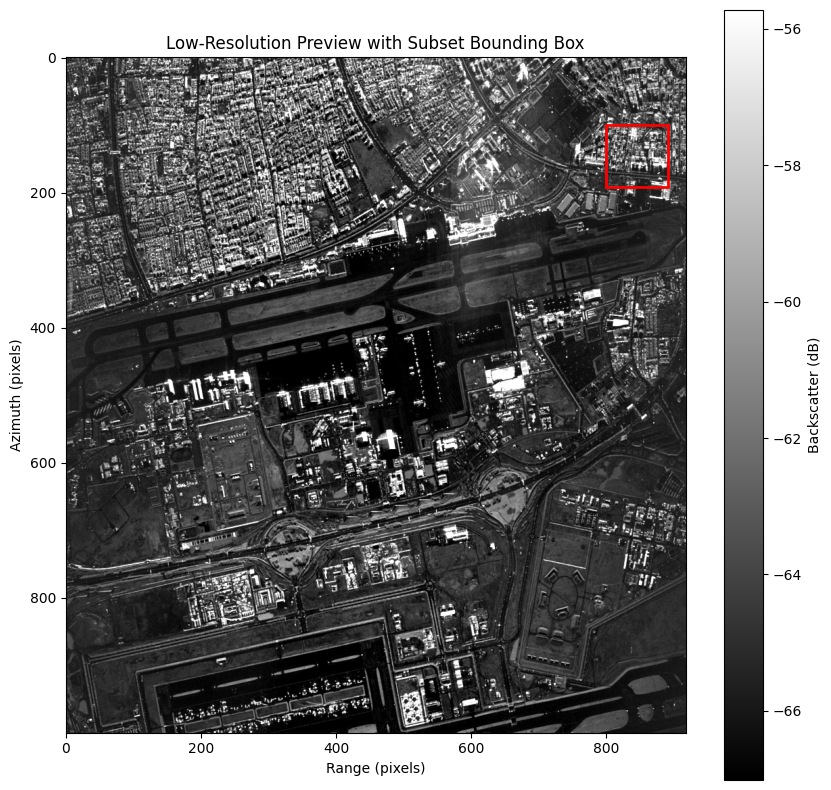

Full image dimensions: 21774 rows × 20000 cols
Preview image dimensions: 1000 rows × 918 cols
Selected preview coordinates: (row=100, col=800)
Mapped to full image: (row_off=2177, col_off=17419) with size 2000x2000
Adjust preview_row and preview_col to select a different region in the preview image.


In [8]:
"""## 3. Preview ICEYE Data with Subset Bounding Box"""

# Define data directory and TIFF filename
data_dir = os.path.join(path, 'sar_sample_data/Qatar_Dwell_Fine_ICEYE_GRD')
tif_filename = 'ICEYE_X20_GRD_SLEDF_4049621_20240429T222841.tif'

# Load low-resolution preview
print('Loading ICEYE preview...')
try:
    preview_db, full_width, full_height, scale_factor = load_iceye_preview(data_dir, tif_filename, max_pixels=1000)
except Exception as e:
    print(f'Error loading preview: {e}')
    sys.exit(1)

# User-defined subset coordinates in PREVIEW image coordinates
# Example: Select a point in the preview where buildings are visible (e.g., at 300, 400)
preview_row = 100  # Row coordinate in the preview image
preview_col = 800  # Column coordinate in the preview image
subset_size = 2000  # Size in full image pixels

# Convert preview coordinates to full image coordinates
row_off = int(preview_row / scale_factor)
col_off = int(preview_col / scale_factor)

# Ensure coordinates are within bounds
row_off = max(0, min(row_off, full_height - subset_size))
col_off = max(0, min(col_off, full_width - subset_size))

# Visualize preview with red bounding box
plt.figure(figsize=(10, 10))
vmin = np.percentile(preview_db, 2)
vmax = np.percentile(preview_db, 98)
plt.imshow(preview_db, cmap='gray', vmin=vmin, vmax=vmax)

# Calculate scaled coordinates for the bounding box
scaled_row_off = row_off * scale_factor
scaled_col_off = col_off * scale_factor
scaled_subset_width = subset_size * scale_factor
scaled_subset_height = subset_size * scale_factor

# Add red bounding box
rect = patches.Rectangle(
    (scaled_col_off, scaled_row_off),
    scaled_subset_width,
    scaled_subset_height,
    linewidth=2,
    edgecolor='red',
    facecolor='none'
)
plt.gca().add_patch(rect)

plt.title('Low-Resolution Preview with Subset Bounding Box')
plt.xlabel('Range (pixels)')
plt.ylabel('Azimuth (pixels)')
plt.colorbar(label='Backscatter (dB)')
plt.show()

print(f'Full image dimensions: {full_height} rows × {full_width} cols')
print(f'Preview image dimensions: {preview_db.shape[0]} rows × {preview_db.shape[1]} cols')
print(f'Selected preview coordinates: (row={preview_row}, col={preview_col})')
print(f'Mapped to full image: (row_off={row_off}, col_off={col_off}) with size {subset_size}x{subset_size}')
print('Adjust preview_row and preview_col to select a different region in the preview image.')

In [9]:
"""## 4. Load ICEYE Data Subset"""

print(f'Loading ICEYE data subset at (row_off={row_off}, col_off={col_off})...')
try:
    sar_image_db, metadata = load_iceye_data_subset(data_dir, tif_filename, row_off=row_off, col_off=col_off, subset_size=subset_size)
except Exception as e:
    print(f'Error loading ICEYE data: {e}')
    sys.exit(1)

# Validate data
if sar_image_db.size == 0 or np.all(np.isnan(sar_image_db)):
    print('Error: Loaded SAR image is empty or contains only NaN values')
    sys.exit(1)

print(f'Loaded ICEYE image subset: {sar_image_db.shape}')
print(f'Sensor: {metadata.get("sensor", "ICEYE")}')
print(f'Mode: {metadata.get("mode", "Spotlight")}')
print(f'Polarization: {metadata.get("polarization", "VV")}')
print(f'Acquisition Date: {metadata.get("acquisition_date", "2024-04-29")}')
print(f'Center Location: {metadata.get("center_lat", 25.26):.2f}°N, {metadata.get("center_lon", 51.57):.2f}°E')
print(f'Incidence Angle: {metadata.get("incidence_angle", 30.5):.1f}°')
print(f'Pixel Spacing: {metadata.get("pixel_spacing_range", 1.0):.2f}m × {metadata.get("pixel_spacing_azimuth", 1.0):.2f}m')
print(f'Data Range: {sar_image_db.min():.1f} to {sar_image_db.max():.1f} dB')

Loading ICEYE data subset at (row_off=2177, col_off=17419)...
Loaded ICEYE image subset: (2000, 2000)
Sensor: ICEYE-X20
Mode: spotlight
Polarization: VV
Acquisition Date: 2024-04-29T22:28:41.593317
Center Location: 25.26°N, 51.57°E
Incidence Angle: 33.0°
Pixel Spacing: 1.00m × 1.00m
Data Range: -74.8 to -11.0 dB


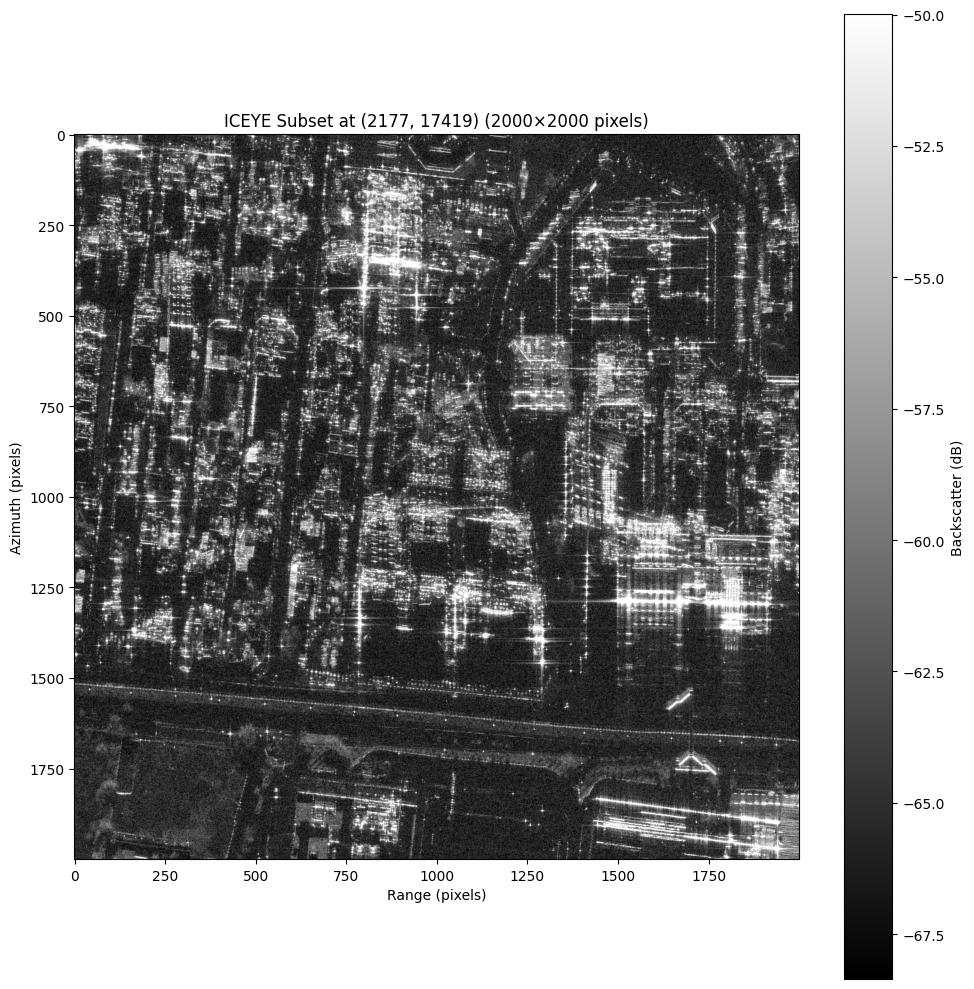

Working with subset: 2000 × 2000 pixels


In [10]:
"""## 5. Data Visualization"""

fig, axes = plt.subplots(1, 1, figsize=(10, 10))
vmin = np.percentile(sar_image_db, 2)
vmax = np.percentile(sar_image_db, 98)
im = axes.imshow(sar_image_db, cmap='gray', vmin=vmin, vmax=vmax)
axes.set_title(f'ICEYE Subset at ({row_off}, {col_off}) ({sar_image_db.shape[0]}×{sar_image_db.shape[1]} pixels)')
axes.set_xlabel('Range (pixels)')
axes.set_ylabel('Azimuth (pixels)')
plt.colorbar(im, ax=axes, label='Backscatter (dB)')
plt.tight_layout()
plt.show()

print(f'Working with subset: {sar_image_db.shape[0]} × {sar_image_db.shape[1]} pixels')

In [27]:
# Memory management for Colab
import gc
import psutil

def check_memory_usage():
    """Check current memory usage"""
    memory = psutil.virtual_memory()
    print(f"Memory usage: {memory.percent:.1f}% ({memory.used/1024**3:.1f}GB / {memory.total/1024**3:.1f}GB)")
    return memory.percent

# Clear memory before processing
gc.collect()
check_memory_usage()

# Method 1: Memory-Efficient Detection
print('Applying memory-efficient detection...')
results_m1 = height_estimation.estimate_building_heights(
    sar_image_db,
    method='memory_efficient',
    min_building_area=100,
    max_building_area=2500,  # Reduced max size
    detection_sensitivity='medium'
)
print(f'Detected {len(results_m1["buildings"])} buildings')
print(f'Height estimates: {results_m1["heights"][:10]}...')  # Show first 10 only

# # Clear memory after processing
# del results
# gc.collect()
# check_memory_usage()

Memory usage: 14.6% (1.5GB / 12.7GB)
Applying memory-efficient detection...
Using memory-efficient method: memory_efficient
Detected 214 buildings
Detected 214 buildings
Height estimates: [np.float64(24.65), np.float64(21.14), np.float64(18.6), np.float64(16.990000000000002), np.float64(14.72), np.float64(13.31), np.float64(12.54), np.float64(11.57), np.float64(10.25), np.float64(10.219999999999999)]...


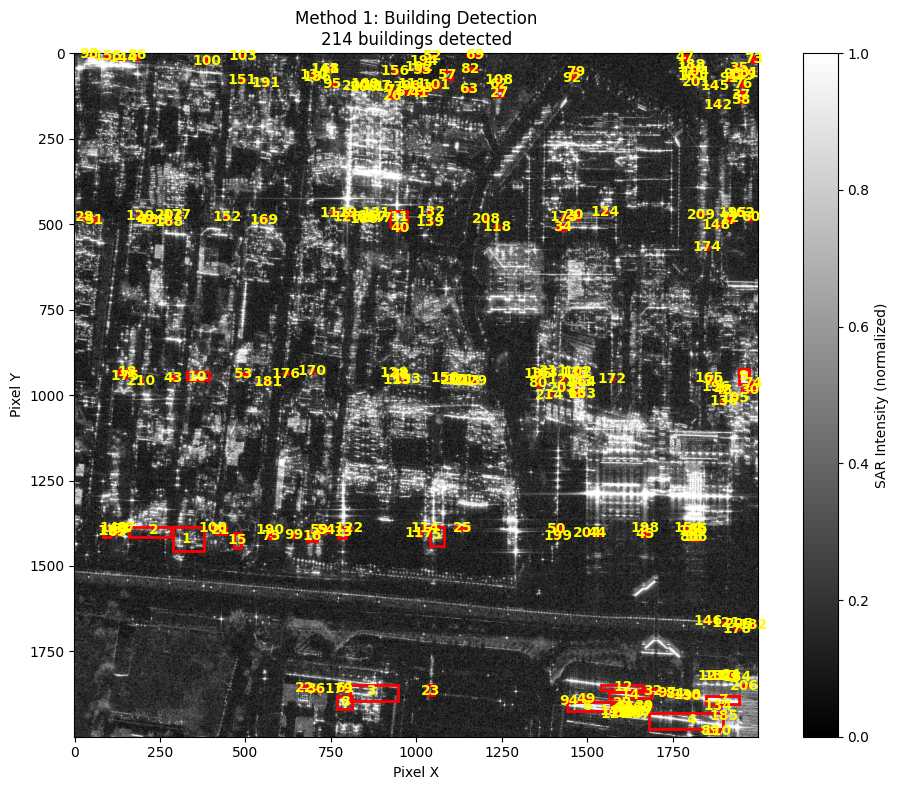

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

In [28]:
# Compact visualization function
def plot_buildings_compact(sar_image, detection_results, title="Building Detection"):
    """
    Compact visualization with buildings overlaid on SAR image.
    """
    plt.figure(figsize=(10, 8))

    # Prepare SAR image for display
    if np.max(sar_image) > 10:
        sar_db = 10 * np.log10(np.maximum(sar_image, 1e-10))
    else:
        sar_db = sar_image.copy()

    sar_display = np.clip((sar_db - np.percentile(sar_db, 2)) /
                         (np.percentile(sar_db, 98) - np.percentile(sar_db, 2)), 0, 1)

    # Display SAR image
    plt.imshow(sar_display, cmap='gray')

    # Overlay buildings
    buildings = detection_results.get('buildings', [])
    heights = detection_results.get('heights', [])

    for i, building in enumerate(buildings):
        bbox = building['bbox']

        # Simple red rectangles for buildings
        rect = patches.Rectangle(
            (bbox[1], bbox[0]),
            bbox[3] - bbox[1], bbox[2] - bbox[0],
            linewidth=2, edgecolor='red', facecolor='none'
        )
        plt.gca().add_patch(rect)

        # Add building number
        centroid = building.get('centroid', ((bbox[0] + bbox[2])/2, (bbox[1] + bbox[3])/2))
        plt.text(centroid[1], centroid[0], str(i+1),
                ha='center', va='center', fontsize=10,
                color='yellow', weight='bold')

    plt.title(f'{title}\n{len(buildings)} buildings detected')
    plt.xlabel('Pixel X')
    plt.ylabel('Pixel Y')
    plt.colorbar(label='SAR Intensity (normalized)')
    plt.tight_layout()
    plt.show()

    return plt.gcf()

# Usage:
plot_buildings_compact(sar_image_db, results_m1, "Method 1: Building Detection")

In [29]:
# Generate general height map
print('Generating general height map from SAR backscatter...')
def generate_height_map_from_sar(sar_image, pixel_spacing=1.0, base_height=0.0):
    from scipy import ndimage
    sar_normalized = (sar_image - sar_image.min()) / (sar_image.max() - sar_image.min())
    sar_smoothed = ndimage.gaussian_filter(sar_normalized, sigma=2.0)
    max_height_range = 50.0
    height_map = base_height + (sar_smoothed * max_height_range)
    return height_map

height_map = generate_height_map_from_sar(
    sar_image_db,
    pixel_spacing=metadata.get('pixel_spacing_range', 1.0),
    base_height=10.0
)
print(f'Generated height map with shape: {height_map.shape}')
print(f'Height range: {height_map.min():.1f} - {height_map.max():.1f} m')
print(f'Mean height: {height_map.mean():.1f} m')

Generating general height map from SAR backscatter...
Generated height map with shape: (2000, 2000)
Height range: 15.2 - 48.7 m
Mean height: 19.2 m


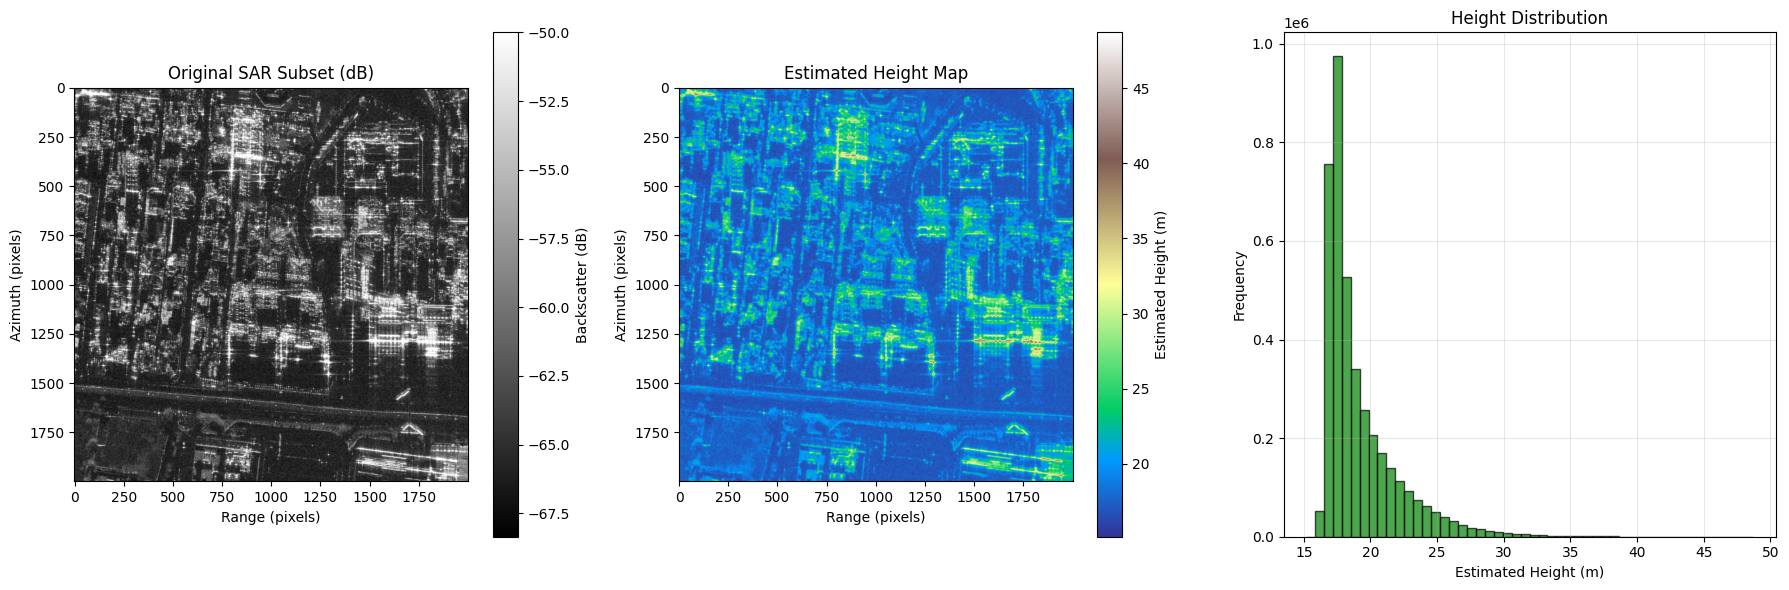

In [30]:
# Visualize height map
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
im1 = axes[0].imshow(sar_image_db, cmap='gray', vmin=vmin, vmax=vmax)
axes[0].set_title('Original SAR Subset (dB)')
axes[0].set_xlabel('Range (pixels)')
axes[0].set_ylabel('Azimuth (pixels)')
plt.colorbar(im1, ax=axes[0], label='Backscatter (dB)')
im2 = axes[1].imshow(height_map, cmap='terrain', aspect='equal')
axes[1].set_title('Estimated Height Map')
axes[1].set_xlabel('Range (pixels)')
axes[1].set_ylabel('Azimuth (pixels)')
plt.colorbar(im2, ax=axes[1], label='Estimated Height (m)')
axes[2].hist(height_map.flatten(), bins=50, alpha=0.7, color='green', edgecolor='black')
axes[2].set_title('Height Distribution')
axes[2].set_xlabel('Estimated Height (m)')
axes[2].set_ylabel('Frequency')
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
# Generate height statistics
print('\n=== General Height Map Statistics ===')
print(f'Total pixels: {height_map.size:,}')
print(f'Height range: {height_map.min():.1f} - {height_map.max():.1f} m')
print(f'Mean height: {height_map.mean():.1f} m')
print(f'Median height: {np.median(height_map):.1f} m')
print(f'Standard deviation: {height_map.std():.1f} m')
percentiles = [10, 25, 50, 75, 90, 95, 99]
print('\nHeight Percentiles:')
for p in percentiles:
    value = np.percentile(height_map, p)
    print(f'  {p}th percentile: {value:.1f} m')


=== General Height Map Statistics ===
Total pixels: 4,000,000
Height range: 15.2 - 48.7 m
Mean height: 19.2 m
Median height: 18.1 m
Standard deviation: 2.8 m

Height Percentiles:
  10th percentile: 16.9 m
  25th percentile: 17.3 m
  50th percentile: 18.1 m
  75th percentile: 20.1 m
  90th percentile: 23.0 m
  95th percentile: 25.0 m
  99th percentile: 29.6 m


In [43]:
bbox_results, shadow_results = results_m1, results_m1

=== Building Height Estimation Results ===
Bounding Box Regression:
  Number of buildings: 214
  Height range: 5.2 - 24.6 m
  Mean height: 6.2 m
  Median height: 5.6 m
  Standard deviation: 2.4 m

Shadow Analysis:
  Number of buildings: 214
  Height range: 5.2 - 24.6 m
  Mean height: 6.2 m
  Median height: 5.6 m
  Standard deviation: 2.4 m


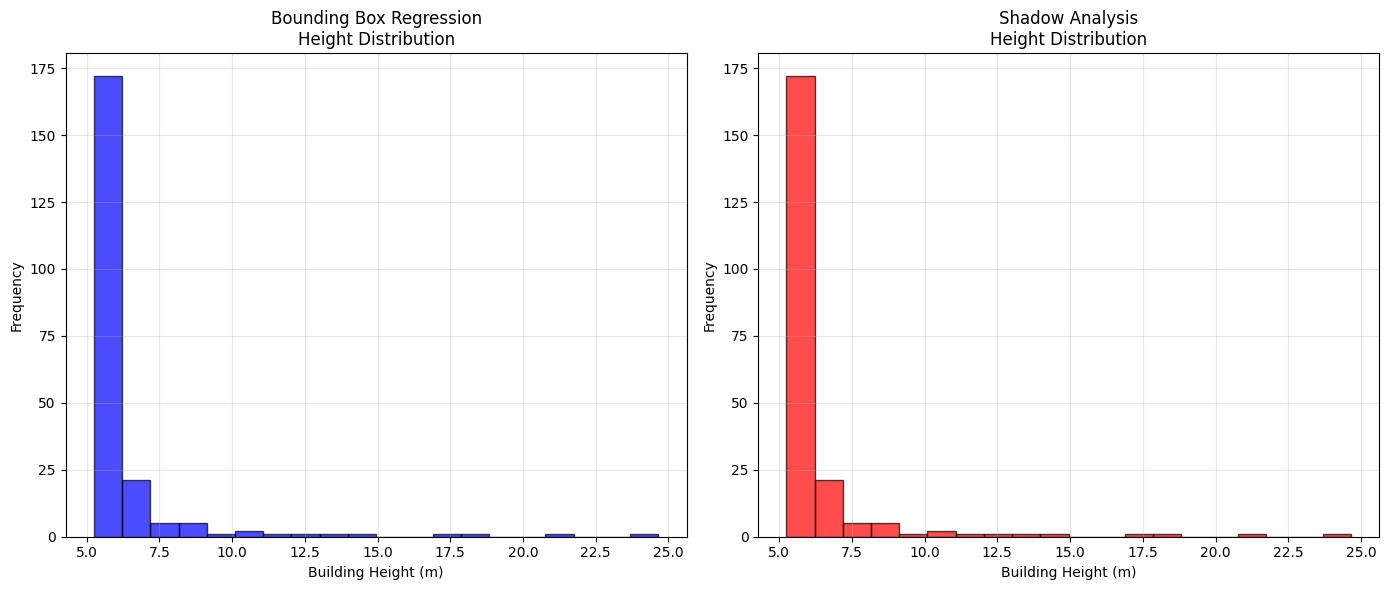

In [44]:
"""## 7. Statistical Analysis"""

print('=== Building Height Estimation Results ===')
if len(bbox_results['heights']) > 0:
    bbox_heights = np.array(bbox_results['heights'])
    print(f'Bounding Box Regression:')
    print(f'  Number of buildings: {len(bbox_heights)}')
    print(f'  Height range: {bbox_heights.min():.1f} - {bbox_heights.max():.1f} m')
    print(f'  Mean height: {bbox_heights.mean():.1f} m')
    print(f'  Median height: {np.median(bbox_heights):.1f} m')
    print(f'  Standard deviation: {bbox_heights.std():.1f} m')
else:
    print('Bounding Box Regression: No buildings detected')
if len(shadow_results['heights']) > 0:
    shadow_heights = np.array(shadow_results['heights'])
    print(f'\nShadow Analysis:')
    print(f'  Number of buildings: {len(shadow_heights)}')
    print(f'  Height range: {shadow_heights.min():.1f} - {shadow_heights.max():.1f} m')
    print(f'  Mean height: {shadow_heights.mean():.1f} m')
    print(f'  Median height: {np.median(shadow_heights):.1f} m')
    print(f'  Standard deviation: {shadow_heights.std():.1f} m')
else:
    print('\nShadow Analysis: No buildings detected')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
if len(bbox_results['heights']) > 0:
    axes[0].hist(bbox_results['heights'], bins=20, alpha=0.7, color='blue', edgecolor='black')
    axes[0].set_title('Bounding Box Regression\nHeight Distribution')
    axes[0].set_xlabel('Building Height (m)')
    axes[0].set_ylabel('Frequency')
    axes[0].grid(True, alpha=0.3)
else:
    axes[0].text(0.5, 0.5, 'No data available', ha='center', va='center', transform=axes[0].transAxes)
if len(shadow_results['heights']) > 0:
    axes[1].hist(shadow_results['heights'], bins=20, alpha=0.7, color='red', edgecolor='black')
    axes[1].set_title('Shadow Analysis\nHeight Distribution')
    axes[1].set_xlabel('Building Height (m)')
    axes[1].set_ylabel('Frequency')
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'No data available', ha='center', va='center', transform=axes[1].transAxes)
plt.tight_layout()
plt.show()

In [ ]:
"""## 8. Save Results"""

output_dir = 'iceye_results'
os.makedirs(output_dir, exist_ok=True)
subset_filename = os.path.join(output_dir, 'iceye_subset.tif')
io.save_geotiff(sar_image_db, subset_filename, metadata.get('transform'), metadata.get('crs'))
results_summary = {
    'metadata': {
        'sensor': metadata.get('sensor', 'ICEYE'),
        'mode': metadata.get('mode', 'Spotlight'),
        'polarization': metadata.get('polarization', 'VV'),
        'acquisition_date': metadata.get('acquisition_date', '2024-04-29'),
        'center_lat': metadata.get('center_lat', 25.26),
        'center_lon': metadata.get('center_lon', 51.57),
        'incidence_angle': metadata.get('incidence_angle', 30.5),
        'pixel_spacing': metadata.get('pixel_spacing_range', 1.0)
    },
    'bbox_regression': {
        'num_buildings': len(bbox_results['buildings']),
        'heights': bbox_results['heights']
    },
    'shadow_analysis': {
        'num_buildings': len(shadow_results['buildings']),
        'heights': shadow_results['heights']
    }
}
import json
results_filename = os.path.join(output_dir, 'height_estimation_results.json')
with open(results_filename, 'w') as f:
    json.dump(results_summary, f, indent=2)
print(f'Results saved to {output_dir}/')